In [ ]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("libraries loaded successfully")

The following section imports data from the American Community Serivce (ACS) Census Bureau Service. I am observing 4 variables for every census tract in Travis County:
# B25064_001E — median gross rent (how much people are paying for rent on average in that tract)
# B19013_001E — median household income (how much people are earning on average)
# B25003_002E — number of owner-occupied housing units (people who own their home)
# B25003_003E — number of renter-occupied units (people who rent)

In [35]:
# load data 

import requests

rent_df = pd.read_csv("median-gross-rent.csv")
income_df = pd.read_csv("median-household-income.csv")

print(rent_df.shape)
print(rent_df.head())


(1, 581)
    Label (Grouping) Census Tract 1.01; Travis County; Texas!!Estimate  \
0  Median gross rent                                             1,837   

  Census Tract 1.01; Travis County; Texas!!Margin of Error  \
0                                               ±192         

  Census Tract 1.02; Travis County; Texas!!Estimate  \
0                                             1,800   

  Census Tract 1.02; Travis County; Texas!!Margin of Error  \
0                                               ±427         

  Census Tract 2.03; Travis County; Texas!!Estimate  \
0                                             2,024   

  Census Tract 2.03; Travis County; Texas!!Margin of Error  \
0                                                ±92         

  Census Tract 2.04; Travis County; Texas!!Estimate  \
0                                             1,430   

  Census Tract 2.04; Travis County; Texas!!Margin of Error  \
0                                               ±293         

  Census 

The next section cleans the imported data. The imported data for rent was wide with one row and 581 columns, so I reshaped it to have one row per census tract. More so, the imported data for income was also one row and 581 columns, so i reshaped that as well.

In [ ]:
# transpose so each tract becomes a row
rent_transposed = rent_df.T.reset_index()
rent_transposed.columns = ["tract_info", "median_rent"]

# keep only the Estimate rows, not Margin of Error
rent_clean = rent_transposed[rent_transposed["tract_info"].str.contains("Estimate")].copy()

# extract just the tract name
rent_clean["tract"] = rent_clean["tract_info"].str.extract(r"(Census Tract [\d.]+)")

# clean up rent values
rent_clean["median_rent"] = pd.to_numeric(rent_clean["median_rent"].str.replace(",", ""), errors="coerce")

rent_clean = rent_clean[["tract", "median_rent"]].dropna()
print(rent_clean.shape)
print(rent_clean.head(10))

# income
income_transposed = income_df.T.reset_index()
income_transposed.columns = ["tract_info", "median_income"]

income_clean = income_transposed[income_transposed["tract_info"].str.contains("Estimate")].copy()
income_clean["tract"] = income_clean["tract_info"].str.extract(r"(Census Tract [\d.]+)")
income_clean["median_income"] = pd.to_numeric(income_clean["median_income"].str.replace(",", ""), errors="coerce")
income_clean = income_clean[["tract", "median_income"]].dropna()


(261, 2)
                tract  median_rent
1   Census Tract 1.01       1837.0
3   Census Tract 1.02       1800.0
5   Census Tract 2.03       2024.0
7   Census Tract 2.04       1430.0
9   Census Tract 2.05       1677.0
11  Census Tract 2.06       1229.0
13  Census Tract 3.02       1292.0
15  Census Tract 3.04       1618.0
17  Census Tract 3.05       1549.0
19  Census Tract 3.07       1876.0
(260, 5)
               tract  median_rent  median_income  annual_rent  rent_burden_pct
0  Census Tract 1.01       1837.0       131713.0      22044.0        16.736389
1  Census Tract 1.02       1800.0       224688.0      21600.0         9.613330
2  Census Tract 2.03       2024.0        88968.0      24288.0        27.299703
3  Census Tract 2.04       1430.0       115375.0      17160.0        14.873239
4  Census Tract 2.05       1677.0        69314.0      20124.0        29.033096
5  Census Tract 2.06       1229.0        97123.0      14748.0        15.184869
6  Census Tract 3.02       1292.0        582

,tract,median_rent,median_income,annual_rent,rent_burden_pct
0,Census Tract 1.01,1837.0,131713.0,22044.0,16.736389
1,Census Tract 1.02,1800.0,224688.0,21600.0,9.613330
2,Census Tract 2.03,2024.0,88968.0,24288.0,27.299703
3,Census Tract 2.04,1430.0,115375.0,17160.0,14.873239
4,Census Tract 2.05,1677.0,69314.0,20124.0,29.033096
...,...,...,...,...,...
255,Census Tract 465,1430.0,67964.0,17160.0,25.248661
256,Census Tract 466,2641.0,126995.0,31692.0,24.955313
257,Census Tract 467,1807.0,160302.0,21684.0,13.526968
258,Census Tract 468,2126.0,152356.0,25512.0,16.744992


From there, I merged the rent and income datasets together. Then, I calculated rent burden (the percent of income spent on rent annually) for later analysis.

In [ ]:

# merge rent and income together
df = pd.merge(rent_clean, income_clean, on="tract")

# calculate rent burden (% of income spent on rent annually)
df["annual_rent"] = df["median_rent"] * 12
df["rent_burden_pct"] = (df["annual_rent"] / df["median_income"]) * 100

print(df.shape)
print(df.head(10))

df

The first visualization I made from my data was a histogram showcasing the distribution of rent burden across all tracts. This chart showed that most tracts cluster right around the 30% threshold, but there's a long tail of tracts where people are spending way more than 30% on rent. Those outliers at 200-400% are likely very low income tracts where rent is eating almost everything.

The second visualization I made was a scatterpplot shwoing the relationship bewteen rent and icnome. This showed that as income goes up, rent goes up too but not proportionally. The tracts with the lowest incomes are still paying $1000-1500/month in rent which is a huge burden relative to what they earn.

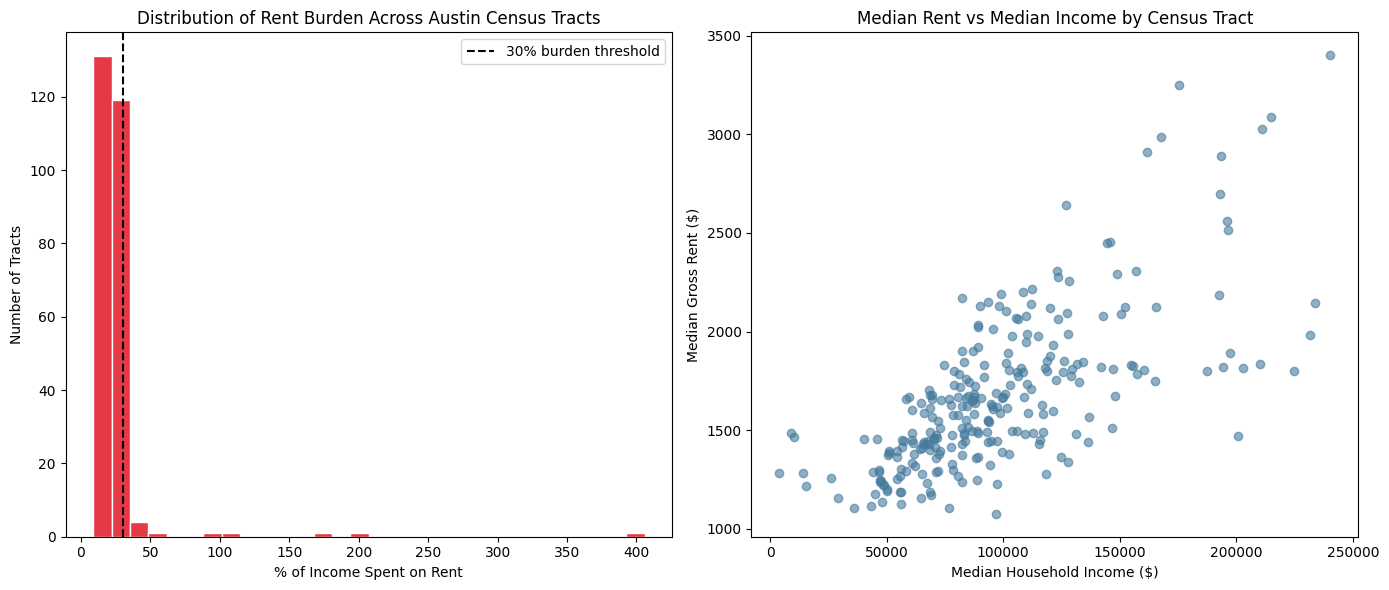

In [30]:
# viusalizations

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# chart 1: distribution of rent burden across all tracts
axes[0].hist(df["rent_burden_pct"].dropna(), bins=30, color="#E63946", edgecolor="white")
axes[0].axvline(x=30, color="black", linestyle="--", label="30% burden threshold")
axes[0].set_title("Distribution of Rent Burden Across Austin Census Tracts")
axes[0].set_xlabel("% of Income Spent on Rent")
axes[0].set_ylabel("Number of Tracts")
axes[0].legend()

# chart 2: rent vs income scatterplot
axes[1].scatter(df["median_income"], df["median_rent"], color="#457B9D", alpha=0.6)
axes[1].set_title("Median Rent vs Median Income by Census Tract")
axes[1].set_xlabel("Median Household Income ($)")
axes[1].set_ylabel("Median Gross Rent ($)")

plt.tight_layout()
plt.show()

Then, I found the most cost-burdened tracts, so the tracts that spend more than 30% of their income on rent.

The results show that Census Tract 6.08 has a median income of only $3,794 but median rent of $1,283 — that's 406% rent burden, meaning rent costs more than 4x their annual income. These are likely extremely low income residents, possibly including people with very unstable or part-time income. Tracts 6.05, 6.06, 6.07 are all clustered together geographically and all showing extreme burden — that's almost certainly the same low-income neighborhood.


In [31]:
# flag cost burdened tracts (over 30%)
df["cost_burdened"] = df["rent_burden_pct"] > 30

print(f"Total tracts: {len(df)}")
print(f"Cost burdened tracts (>30%): {df['cost_burdened'].sum()}")
print(f"Percentage of tracts cost burdened: {df['cost_burdened'].mean()*100:.1f}%")

# show the 10 most burdened tracts
print("\nTop 10 most rent-burdened tracts:")
df.nlargest(10, "rent_burden_pct")[["tract", "median_rent", "median_income", "rent_burden_pct"]]

Total tracts: 260
Cost burdened tracts (>30%): 33
Percentage of tracts cost burdened: 12.7%

Top 10 most rent-burdened tracts:


,tract,median_rent,median_income,rent_burden_pct
19,Census Tract 6.08,1283.0,3794.0,405.798629
16,Census Tract 6.05,1488.0,9060.0,197.086093
17,Census Tract 6.06,1467.0,10212.0,172.385429
18,Census Tract 6.07,1284.0,14231.0,108.270677
15,Census Tract 6.01,1215.0,15545.0,93.792216
98,Census Tract 23.27,1256.0,25900.0,58.193050
199,Census Tract 407,1158.0,29253.0,47.502820
225,Census Tract 433,1453.0,40260.0,43.308495
105,Census Tract 24.13,1453.0,45733.0,38.125642
224,Census Tract 432,1105.0,36117.0,36.714013


I then visualized the top 10 omst burndedn tracts using a bar chart. This ended up showing that Census Tract 6.08 is a massive outlier at 400%+ which visually jumps out immediately.

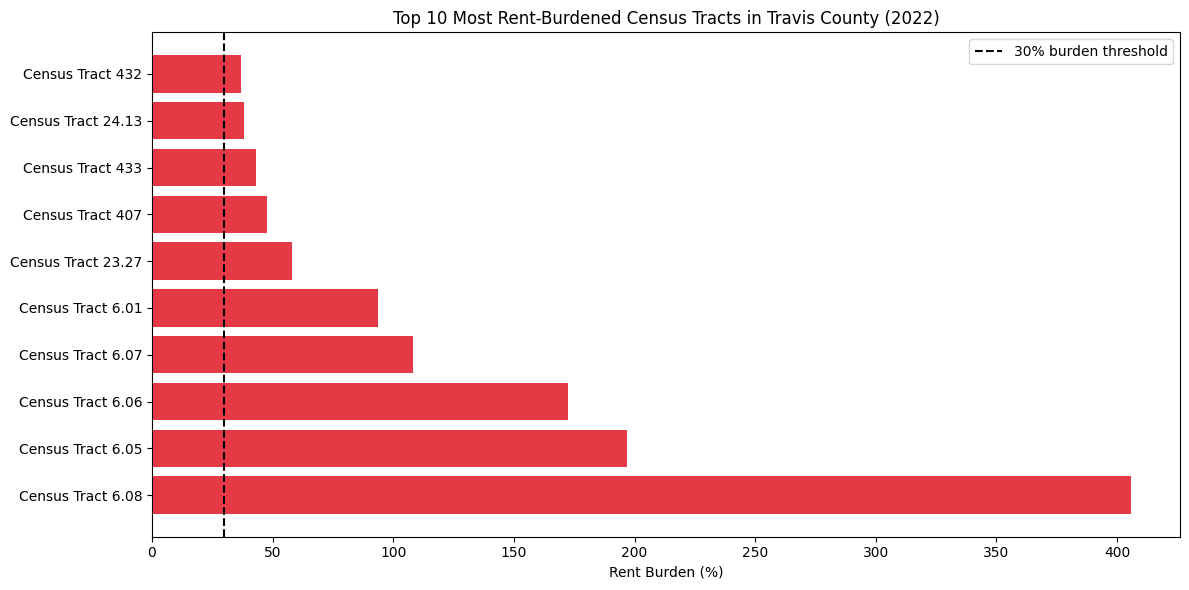

In [ ]:
# bar chart of top 10 most burdened tracts

top10 = df.nlargest(10, "rent_burden_pct")

plt.figure(figsize=(12, 6))
plt.barh(top10["tract"], top10["rent_burden_pct"], color="#E63946")
plt.axvline(x=30, color="black", linestyle="--", label="30% burden threshold")
plt.xlabel("Rent Burden (%)")
plt.title("Top 10 Most Rent-Burdened Census Tracts in Travis County (2022)")
plt.legend()
plt.tight_layout()
plt.show()

I additionally conducted a correlation analysis to see the relationship between rent burden and income.

The results were r = -0.401, a moderate negative correlation, meaning as income goes up, rent burden goes down. This suports the intuitive idea that richer neighborhoods can afford rent more easily. The p-value of p < 0.001 indicates that the above finding is highly statistically significant.

In [33]:
from scipy import stats

corr, pvalue = stats.pearsonr(df["median_income"].dropna(), df["rent_burden_pct"].dropna())
print(f"Correlation between income and rent burden: {corr:.3f}")
print(f"P-value: {pvalue:.15f}")

Correlation between income and rent burden: -0.401
P-value: 0.000000000019423


Lastly, I conducted a linear regression model that predicts rent burden from income. 

The R² of 0.118 means income and rent alone only explain about 12% of the variance in rent burden. This indicates that rent burden is driven by a lot more than just income and rent (household size, job stability, number of earners, etc).

The RMSE of 51 is high because of those extreme outlier tracts like 6.08 that are skewing everything.

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# prepare data
ml_df = df[["median_income", "median_rent", "rent_burden_pct"]].dropna()

X = ml_df[["median_income", "median_rent"]]
y = ml_df["rent_burden_pct"]

# split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train model
model = LinearRegression()
model.fit(X_train, y_train)

# evaluate
y_pred = model.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred)**.5:.2f}")

R² Score: 0.118
RMSE: 51.44
